# Phase 2 — CLF model Training 


In [6]:
# Imports and GPU check
import os
from pathlib import Path
import zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA used by PyTorch:", torch.version.cuda)
else:
    print("CUDA not available. Training will run on CPU.")


Device: cpu
CUDA not available. Training will run on CPU.


In [7]:
# Local project paths
PROJECT_ROOT = Path(r"/Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project")

DATASET_ZIP = PROJECT_ROOT / "dataset.zip"
DATASET_ROOT = PROJECT_ROOT / "dataset"
PROCESSED_ROOT = PROJECT_ROOT / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT   :", PROJECT_ROOT)
print("DATASET_ROOT   :", DATASET_ROOT)
print("PROCESSED_ROOT :", PROCESSED_ROOT)
print("MODEL_DIR      :", MODEL_DIR)
print("OUTPUTS_DIR    :", OUTPUTS_DIR)

PROJECT_ROOT   : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project
DATASET_ROOT   : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset
PROCESSED_ROOT : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/processed
MODEL_DIR      : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/models
OUTPUTS_DIR    : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/outputs


In [8]:
#extracting dataset.zip only if needed
if not DATASET_ROOT.exists():
    if DATASET_ZIP.exists():
        print("Dataset folder not found. Extracting dataset.zip...")
        DATASET_ROOT.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(DATASET_ZIP, "r") as z:
            z.extractall(DATASET_ROOT)
        print("Extraction complete.")
    else:
        print("Dataset folder and dataset.zip were not found.")
        print("Put dataset.zip here:", DATASET_ZIP)
else:
    print("Dataset folder already exists:", DATASET_ROOT)


Dataset folder already exists: /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset


In [9]:
# Quick folder check
for p in [DATASET_ROOT, PROCESSED_ROOT, MODEL_DIR]:
    print("\n", p)
    if p.exists():
        for item in list(p.iterdir())[:10]:
            print("  -", item.name)
    else:
        print("  NOT FOUND")



 /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset
  - .DS_Store
  - hw2p2_sample_submission.csv
  - verification_pairs_test.txt
  - classification_data
  - verification_pairs_val.txt
  - verification_data

 /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/processed
  - .DS_Store
  - classification_data
  - verification_data

 /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/models
  - trip_model_final.pth
  - .DS_Store
  - clf_model_best.pth
  - spoof_model_best.pth
  - emotion_model.pkl


In [10]:
# Dataset paths
PROC_TRAIN = PROCESSED_ROOT / "classification_data" / "train_data"
PROC_VAL   = PROCESSED_ROOT / "classification_data" / "val_data"
PROC_TEST  = PROCESSED_ROOT / "classification_data" / "test_data"
PROC_VERIF = PROCESSED_ROOT / "verification_data"

# Find verification_pairs_val.txt flexibly inside the dataset folder
pair_candidates = list(DATASET_ROOT.rglob("verification_pairs_val.txt")) if DATASET_ROOT.exists() else []
if pair_candidates:
    VERIF_PAIRS = pair_candidates[0]
else:
    VERIF_PAIRS = DATASET_ROOT / "verification_pairs_val.txt"

print("PROC_TRAIN :", PROC_TRAIN)
print("PROC_VAL   :", PROC_VAL)
print("PROC_VERIF :", PROC_VERIF)
print("VERIF_PAIRS:", VERIF_PAIRS)

# Stop early with helpful messages if important folders are missing
required_paths = [PROC_TRAIN, PROC_VAL, PROC_VERIF, VERIF_PAIRS]
missing = [p for p in required_paths if not p.exists()]
if missing:
    print("\nMissing required paths:")
    for p in missing:
        print(" -", p)
    raise FileNotFoundError("Some Phase 2 input folders/files are missing. Check PROJECT_ROOT and Phase 1 outputs.")

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


class ClassificationDataset(Dataset):
    def __init__(self, root_dir, transform=EVAL_TRANSFORM):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self.identity_to_idx = {}

        for idx, identity in enumerate(sorted(os.listdir(self.root_dir))):
            id_dir = self.root_dir / identity
            if not id_dir.is_dir():
                continue
            self.identity_to_idx[identity] = idx
            for fname in os.listdir(id_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.samples.append((id_dir / fname, idx))

        self.idx_to_identity = {v: k for k, v in self.identity_to_idx.items()}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

    @property
    def num_classes(self):
        return len(self.identity_to_idx)


class VerificationDataset(Dataset):
    def __init__(self, pairs_file, img_dir, transform=EVAL_TRANSFORM):
        self.transform = transform
        self.img_dir = Path(img_dir)
        self.pairs = []

        # Index all available processed verification images
        self.image_index = {}

        image_files = (
            list(self.img_dir.rglob("*.jpg")) +
            list(self.img_dir.rglob("*.jpeg")) +
            list(self.img_dir.rglob("*.png"))
        )

        for path in image_files:
            self.image_index[path.name] = path
            self.image_index[path.stem] = path

        print("Verification images found:", len(image_files))

        skipped = 0

        with open(pairs_file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) != 3:
                    continue

                img1 = parts[0]
                img2 = parts[1]
                label = int(parts[2])

                img1_path = self.resolve_path_or_none(img1)
                img2_path = self.resolve_path_or_none(img2)

                if img1_path is None or img2_path is None:
                    skipped += 1
                    continue

                self.pairs.append((img1_path, img2_path, label))

        print("Valid verification pairs:", len(self.pairs))
        print("Skipped pairs due to missing images:", skipped)

    def resolve_path_or_none(self, name):
        name = Path(name)

        # Remove leading verification_data if pair file includes it
        if len(name.parts) > 1 and name.parts[0] == "verification_data":
            name = Path(*name.parts[1:])

        direct_path = self.img_dir / name

        if direct_path.exists():
            return direct_path

        if name.name in self.image_index:
            return self.image_index[name.name]

        if name.stem in self.image_index:
            return self.image_index[name.stem]

        return None

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.long)
    
train_ds = ClassificationDataset(PROC_TRAIN, transform=TRAIN_TRANSFORM)
val_ds = ClassificationDataset(PROC_VAL, transform=EVAL_TRANSFORM)
verif_ds = VerificationDataset(
    pairs_file=VERIF_PAIRS,
    img_dir=PROC_VERIF,
    transform=EVAL_TRANSFORM
)

BATCH_SIZE = 64 if device.type == "cuda" else 32
PIN_MEMORY = True if device.type == "cuda" else False

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)
verif_loader = DataLoader(
    verif_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

NUM_CLASSES = train_ds.num_classes
print(f"Batch size : {BATCH_SIZE}")
print(f"Train      : {len(train_ds):,} samples")
print(f"Val        : {len(val_ds):,} samples")
print(f"Identities : {NUM_CLASSES}")
print(f"Verif pairs: {len(verif_ds):,}")


PROC_TRAIN : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/processed/classification_data/train_data
PROC_VAL   : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/processed/classification_data/val_data
PROC_VERIF : /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/processed/verification_data
VERIF_PAIRS: /Users/nishenpallawala/Desktop/SWIN/SEM 6/AppliedML_Project/dataset/verification_pairs_val.txt
Verification images found: 63593
Valid verification pairs: 7733
Skipped pairs due to missing images: 1072
Batch size : 32
Train      : 110,091 samples
Val        : 7,936 samples
Identities : 4000
Verif pairs: 7,733


In [11]:
class FaceEmbedderClassification(nn.Module):
    def __init__(self, num_classes, embed_dim=512):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        # Freeze early layers, fine-tune from layer 14 onwards
        for i, layer in enumerate(base.features):
            if i < 14:
                for p in layer.parameters():
                    p.requires_grad = False
        self.backbone   = base.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.embedder   = nn.Sequential(
            nn.Linear(1280, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True)
        )
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        feat = self.pool(self.backbone(x)).flatten(1)
        emb  = self.embedder(feat)
        return self.classifier(emb), emb

    def get_embedding(self, x):
        feat = self.pool(self.backbone(x)).flatten(1)
        return F.normalize(self.embedder(feat), dim=1)


clf_model = FaceEmbedderClassification(NUM_CLASSES).to(device)
trainable = sum(p.numel() for p in clf_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

Trainable parameters: 4,390,240


In [12]:
CLF_EPOCHS = 10
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, clf_model.parameters()),
    lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2,
    epochs=CLF_EPOCHS,
    steps_per_epoch=len(train_loader))

clf_history = {'train_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

for ep in range(1, CLF_EPOCHS + 1):
    # Train
    clf_model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'[CLF] Epoch {ep}/{CLF_EPOCHS}'):
        imgs, labels = imgs.to(device), labels.to(device)
        logits, _    = clf_model(imgs)
        loss         = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * len(imgs)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(imgs)

    # Val
    clf_model.eval()
    vcorrect, vn = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _    = clf_model(imgs)
            vcorrect     += (logits.argmax(1) == labels).sum().item()
            vn           += len(imgs)

    tr_loss = total_loss / n
    tr_acc  = correct / n
    val_acc = vcorrect / vn

    clf_history['train_loss'].append(tr_loss)
    clf_history['train_acc'].append(tr_acc)
    clf_history['val_acc'].append(val_acc)

    print(f'Ep {ep:02d} | loss={tr_loss:.4f} | train={tr_acc:.3f} | val={val_acc:.3f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(clf_model.state_dict(), MODEL_DIR / 'clf_model_best.pth')
        print(f'  ✅ Saved best model (val={val_acc:.3f})')

print(f'\nBest val accuracy: {best_val_acc:.3f}')

[CLF] Epoch 1/10:   1%|          | 25/3441 [00:21<48:32,  1.17it/s] 


KeyboardInterrupt: 

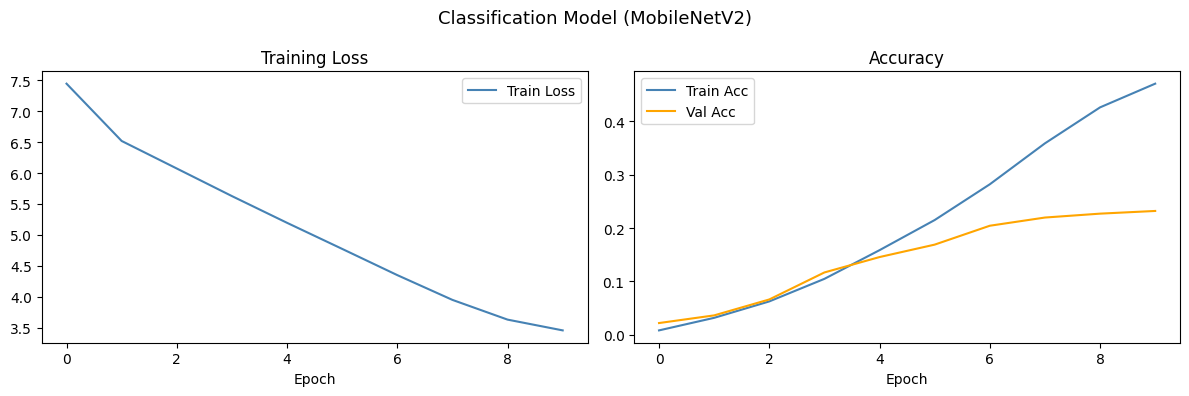

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(clf_history['train_loss'], label='Train Loss', color='steelblue')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(clf_history['train_acc'], label='Train Acc', color='steelblue')
ax2.plot(clf_history['val_acc'],   label='Val Acc',   color='orange')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.suptitle('Classification Model (MobileNetV2)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
class FaceEmbedderTriplet(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Freeze early layers, fine-tune from layer3 onwards
        for name, param in base.named_parameters():
            if not any(name.startswith(s) for s in ['layer3', 'layer4', 'fc']):
                param.requires_grad = False
        in_features = base.fc.in_features
        base.fc     = nn.Identity()
        self.backbone = base
        self.head     = nn.Sequential(
            nn.Linear(in_features, embed_dim),
            nn.BatchNorm1d(embed_dim)
        )

    def forward(self, x):
        return F.normalize(self.head(self.backbone(x)), dim=1)

    def get_embedding(self, x):
        return self.forward(x)


class OnlineTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        sq_dists = torch.cdist(embeddings, embeddings, p=2).pow(2)
        labels   = labels.unsqueeze(1)
        pos_mask = (labels == labels.T) & ~torch.eye(
            len(labels), dtype=torch.bool, device=device)
        neg_mask = labels != labels.T

        # Hardest positive
        ap_dist = (sq_dists * pos_mask.float()).max(dim=1).values

        # Semi-hard negative
        ap_expand  = ap_dist.unsqueeze(1).expand_as(sq_dists)
        semi_hard  = neg_mask & (sq_dists > ap_expand) & \
                     (sq_dists < ap_expand + self.margin)
        large      = sq_dists.max() + 1
        neg_dists  = torch.where(semi_hard, sq_dists,
                     torch.where(neg_mask, sq_dists,
                     large * torch.ones_like(sq_dists)))
        an_dist    = neg_dists.min(dim=1).values

        return F.relu(ap_dist - an_dist + self.margin).mean()


trip_model = FaceEmbedderTriplet().to(device)
print(f'Trainable parameters: {sum(p.numel() for p in trip_model.parameters() if p.requires_grad):,}')

Trainable parameters: 10,625,280


In [ ]:
TRIP_EPOCHS    = 10
trip_criterion = OnlineTripletLoss(margin=0.3)
trip_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, trip_model.parameters()),
    lr=5e-4, weight_decay=1e-4)
trip_scheduler = torch.optim.lr_scheduler.StepLR(
    trip_optimizer, step_size=4, gamma=0.5)

trip_history = []

for ep in range(1, TRIP_EPOCHS + 1):
    trip_model.train()
    total_loss, n = 0.0, 0
    for imgs, labels in tqdm(train_loader, desc=f'[TRIP] Epoch {ep}/{TRIP_EPOCHS}'):
        imgs, labels = imgs.to(device), labels.to(device)
        embs         = trip_model(imgs)
        loss         = trip_criterion(embs, labels)
        trip_optimizer.zero_grad()
        loss.backward()
        trip_optimizer.step()
        total_loss += loss.item() * len(imgs)
        n          += len(imgs)
    trip_scheduler.step()
    avg = total_loss / n
    trip_history.append(avg)
    print(f'Ep {ep:02d} | triplet_loss={avg:.4f}')

torch.save(trip_model.state_dict(), MODEL_DIR / 'trip_model_final.pth')
print('Triplet model saved.')

[TRIP] Epoch 1/10: 100%|██████████| 1717/1717 [06:12<00:00,  4.60it/s]


Ep 01 | triplet_loss=0.0249


[TRIP] Epoch 2/10: 100%|██████████| 1717/1717 [04:57<00:00,  5.78it/s]


Ep 02 | triplet_loss=0.0211


[TRIP] Epoch 3/10: 100%|██████████| 1717/1717 [04:22<00:00,  6.55it/s]


...

Ep 08 | triplet_loss=0.0129


[TRIP] Epoch 9/10: 100%|██████████| 1717/1717 [03:54<00:00,  7.31it/s]


Ep 09 | triplet_loss=0.0118


[TRIP] Epoch 10/10: 100%|██████████| 1717/1717 [03:57<00:00,  7.22it/s]


Ep 10 | triplet_loss=0.0122
✅ Triplet model saved.


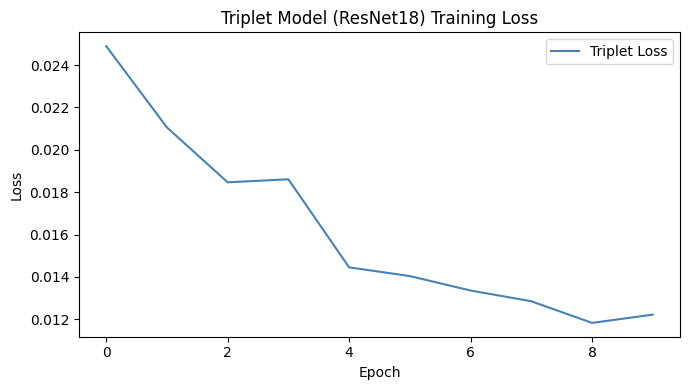

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(trip_history, color='steelblue', label='Triplet Loss')
plt.title('Triplet Model (ResNet18) Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Load best classification model
clf_model.load_state_dict(
    torch.load(MODEL_DIR / 'clf_model_best.pth', map_location=device))
clf_model.eval()
trip_model.eval()


def compute_scores(model, loader, metric='cosine'):
    all_scores, all_labels = [], []
    with torch.no_grad():
        for img1, img2, labels in tqdm(loader, desc=f'{metric}'):
            e1 = model.get_embedding(img1.to(device))
            e2 = model.get_embedding(img2.to(device))
            if metric == 'cosine':
                scores = F.cosine_similarity(e1, e2).cpu().numpy()
            else:
                scores = -torch.norm(e1 - e2, dim=1).cpu().numpy()
            all_scores.extend(scores)
            all_labels.extend(labels.numpy())
    return np.array(all_scores), np.array(all_labels)


results = {}
configs = [
    (clf_model,  'CLF MobileNetV2'),
    (trip_model, 'Triplet ResNet18'),
]

for model, name in configs:
    for metric in ['cosine', 'euclidean']:
        scores, labels = compute_scores(model, verif_loader, metric)
        key            = f'{name} + {metric}'
        results[key]   = (scores, labels)
        fpr, tpr, _    = roc_curve(labels, scores)
        roc_auc        = auc(fpr, tpr)
        print(f'{key:40s}  AUC = {roc_auc:.4f}')

C:\Users\malee\AppData\Local\Temp\ipykernel_30748\3483009969.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(MODEL_DIR / 'clf_model_best.pth', map_location=de

CLF MobileNetV2 + cosine                  AUC = 0.7715


euclidean: 100%|██████████| 100/100 [00:11<00:00,  8.76it/s]


CLF MobileNetV2 + euclidean               AUC = 0.7715


cosine: 100%|██████████| 100/100 [00:11<00:00,  8.43it/s]


Triplet ResNet18 + cosine                 AUC = 0.7976


euclidean: 100%|██████████| 100/100 [00:11<00:00,  8.36it/s]

Triplet ResNet18 + euclidean              AUC = 0.7976


In [ ]:
import pandas as pd
import json

comparison_rows = []

for key, (scores, labels) in results.items():
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    # Youden's J statistic: best balance between TPR and FPR
    best_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[best_idx]

    comparison_rows.append({
        "Configuration": key,
        "AUC": float(roc_auc),
        "Best Threshold": float(best_threshold),
        "TPR": float(tpr[best_idx]),
        "FPR": float(fpr[best_idx])
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("AUC", ascending=False).reset_index(drop=True)

comparison_df

,Configuration,AUC,Best Threshold,TPR,FPR
0,Triplet ResNet18 + cosine,0.797589,0.336370,0.829739,0.374886
1,Triplet ResNet18 + euclidean,0.797589,-1.152068,0.829739,0.374886
2,CLF MobileNetV2 + cosine,0.771539,0.233769,0.703573,0.297775
3,CLF MobileNetV2 + euclidean,0.771538,-1.237926,0.703573,0.297775


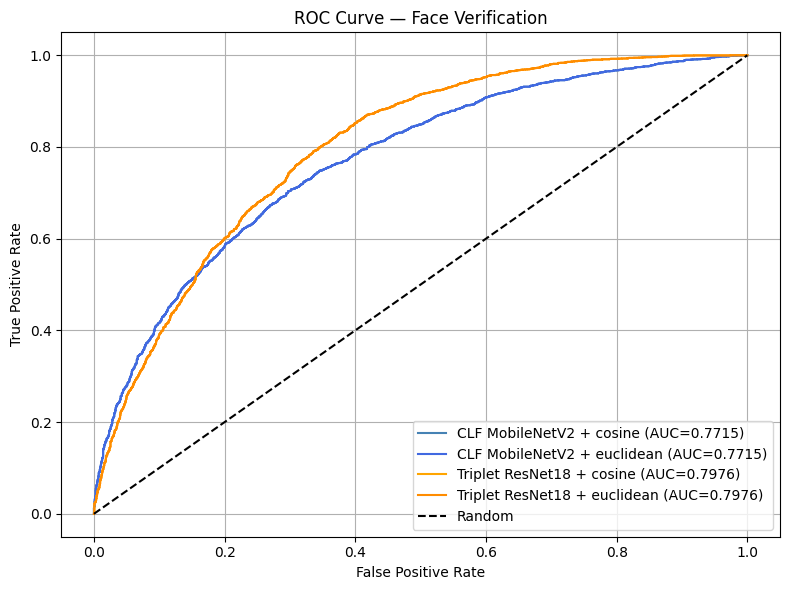

ROC curve saved to: D:\Swinburne\Year 4\Semester 1\Applied Machine Learning\Project\New\outputs\phase2_roc_curve_comparison.png


In [ ]:
plt.figure(figsize=(8, 6))

colors = ['steelblue', 'royalblue', 'orange', 'darkorange']

for (key, (scores, labels)), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=color,
        label=f'{key} (AUC={roc_auc:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Face Verification')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

roc_path = OUTPUTS_DIR / "phase2_roc_curve_comparison.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")

plt.show()

print("ROC curve saved to:", roc_path)

In [ ]:
# Selecting best setup based on highest AUC
best_row = comparison_df.iloc[0]

best_key = best_row["Configuration"]
best_auc = best_row["AUC"]
best_threshold = best_row["Best Threshold"]

print("Best configuration:")
print("-------------------")
print(f"Model + metric : {best_key}")
print(f"AUC            : {best_auc:.4f}")
print(f"Threshold      : {best_threshold:.4f}")
print(f"TPR            : {best_row['TPR']:.4f}")
print(f"FPR            : {best_row['FPR']:.4f}")

# Save comparison table
comparison_csv_path = OUTPUTS_DIR / "phase2_verification_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

# Save best setup info
best_model_info = {
    "best_configuration": str(best_key),
    "best_auc": float(best_auc),
    "best_threshold": float(best_threshold),
    "best_tpr": float(best_row["TPR"]),
    "best_fpr": float(best_row["FPR"]),
    "classification_model_path": str(MODEL_DIR / "clf_model_best.pth"),
    "triplet_model_path": str(MODEL_DIR / "trip_model_final.pth")
}

best_info_path = OUTPUTS_DIR / "phase2_best_face_verification_info.json"

with open(best_info_path, "w") as f:
    json.dump(best_model_info, f, indent=4)

print("\nSaved files:")
print("Comparison CSV :", comparison_csv_path)
print("Best info JSON :", best_info_path)
print("ROC curve image:", roc_path)

print("\nPhase 2 complete — models trained, evaluated, and results saved.")
print("Save these for Phase 5:")
print(f"  clf_model_best.pth   → {MODEL_DIR / 'clf_model_best.pth'}")
print(f"  trip_model_final.pth → {MODEL_DIR / 'trip_model_final.pth'}")
print(f"  best threshold       → {best_threshold:.4f}")